In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/Housing.csv')

df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
207,4900000,3000,3,1,2,yes,no,yes,no,yes,0,no,semi-furnished
154,5530000,3650,3,2,2,yes,no,no,no,no,2,no,semi-furnished
38,7962500,6000,3,1,4,yes,yes,no,no,yes,2,no,unfurnished
378,3640000,2275,3,1,3,yes,no,no,yes,yes,0,yes,semi-furnished
424,3360000,3100,3,1,2,no,no,yes,no,no,0,no,semi-furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
df.duplicated().sum()

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

In [19]:
print(f"Unique Mainroad: {df['mainroad'].unique()}")
print(f"Unique Guestroom: {df['guestroom'].unique()}")
print(f"Unique HotWaterHeating: {df['hotwaterheating'].unique()}")
print(f"Unique Basement: {df['basement'].unique()}")
print(f"Unique AirConditioning: {df['airconditioning'].unique()}")
print(f"Unique PrefArea: {df['prefarea'].unique()}")
print(f"Unique FurnishingStatus: {df['furnishingstatus'].unique()}")


Unique Mainroad: ['yes' 'no']
Unique Guestroom: ['no' 'yes']
Unique HotWaterHeating: ['no' 'yes']
Unique Basement: ['no' 'yes']
Unique AirConditioning: ['yes' 'no']
Unique PrefArea: ['yes' 'no']
Unique FurnishingStatus: ['furnished' 'semi-furnished' 'unfurnished']


In [21]:
yes_no_columns = [
    col for col in df.columns
    if set(df[col].dropna().unique()) == {'yes', 'no'}
]

df[yes_no_columns] = df[yes_no_columns].replace({'yes': 1, 'no': 0})

In [22]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
174,5250000,3800,3,1,2,1,1,1,0,0,1,1,unfurnished
518,2450000,3500,2,1,1,1,1,0,0,0,0,0,unfurnished
86,6510000,6670,3,1,3,1,0,1,0,0,0,1,unfurnished
52,7350000,6000,4,2,4,1,1,0,0,1,1,0,furnished
132,5810000,5200,3,1,3,1,0,0,0,1,0,0,semi-furnished


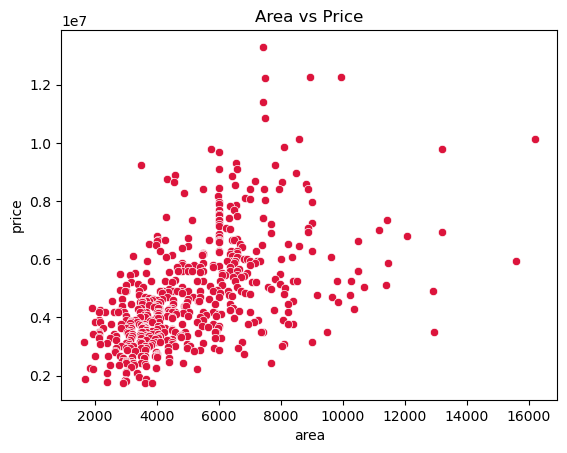

In [27]:
sns.scatterplot(data = df, x = 'area', y = 'price', color = 'crimson')
plt.xlabel('area')
plt.ylabel('price')
plt.title('Area vs Price')
plt.show()

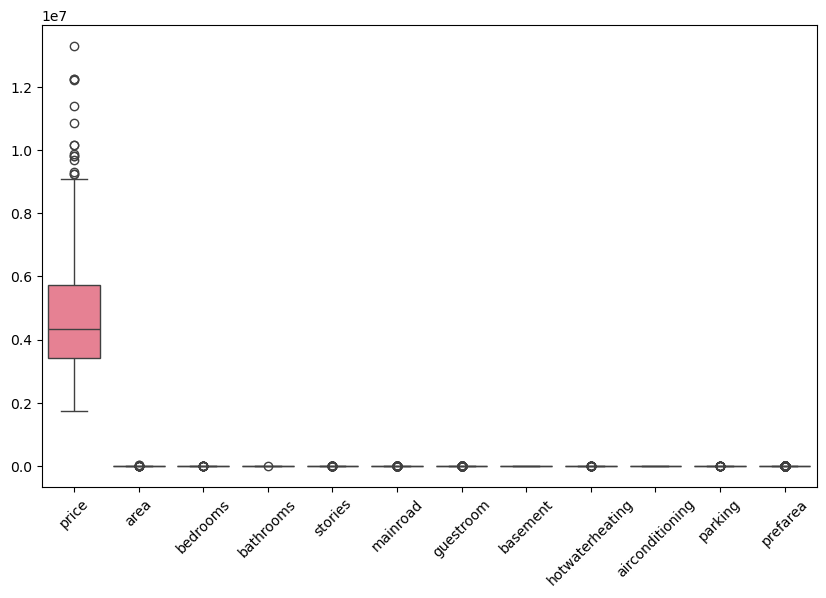

In [ ]:
numerical = df.select_dtypes(include = 'int64').columns.tolist()

plt.figure(figsize=(10,6))

sns.boxplot(data=df[numerical])

plt.xticks(rotation=45)

plt.show()

In [33]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

df = df[
    (df["price"] >= Q1 - 1.5*IQR) &
    (df["price"] <= Q3 + 1.5*IQR)
]

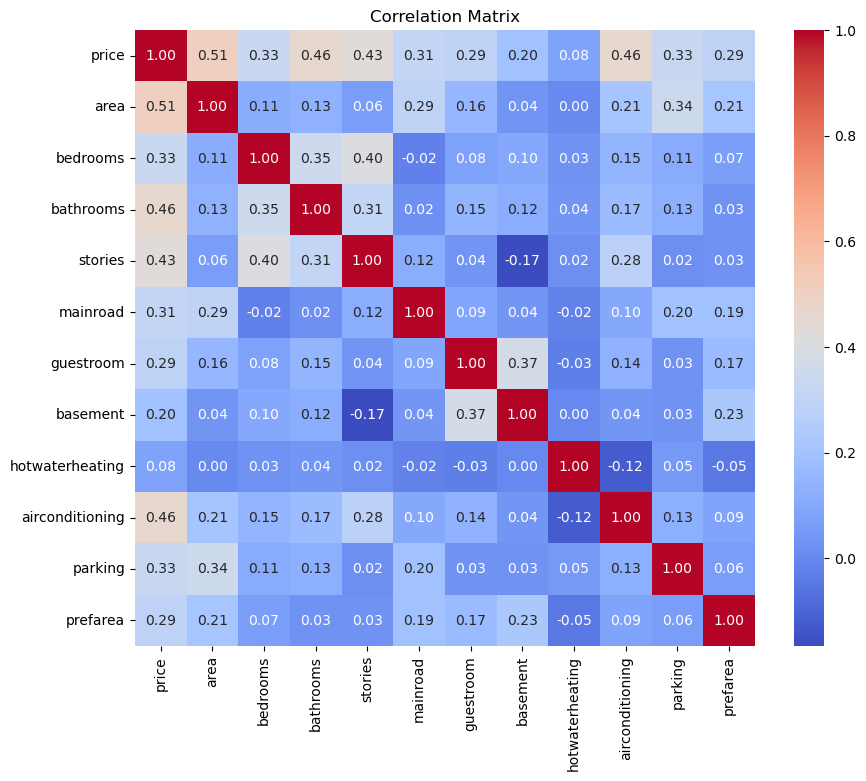

In [64]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [123]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

In [124]:
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


numeric_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [125]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning', 'parking',
                                                   'prefarea']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder())]),
                                                  ['furnishingstatus'])])),
                ('regressor', LinearRegression())])

In [126]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 787275.283018868
RMSE: 1030262.3625083849
R2: 0.5955224488905655


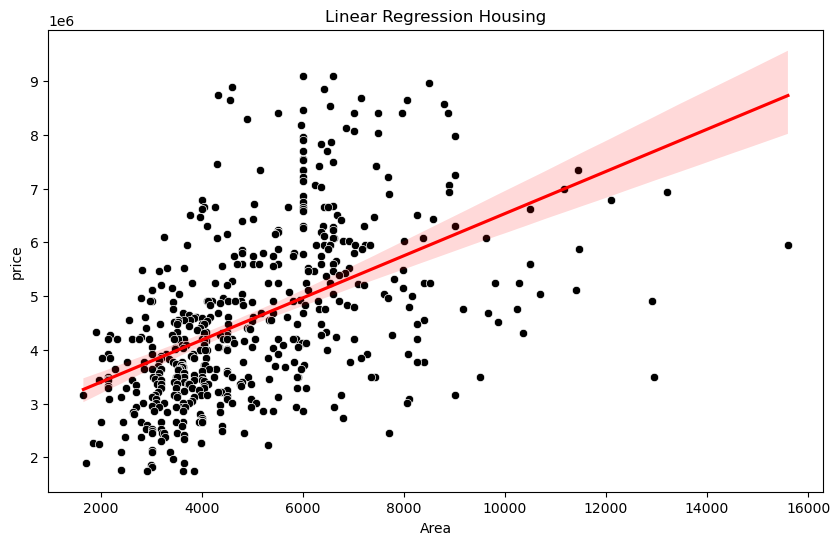

In [127]:
plt.figure(figsize= (10,6))
sns.scatterplot(
    x= 'area',
    y = 'price',
    data = df,
    color = 'black'
)
sns.regplot(x= 'area',
    y = 'price',
    data = df,
    scatter= False,
    color= 'red')

plt.xlabel('Area')
plt.ylabel('price')
plt.title('Linear Regression Housing')
plt.show()


In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

MAE: 617576.3441945581
RMSE: 865074.1844116324
R2: 0.7065921120276715


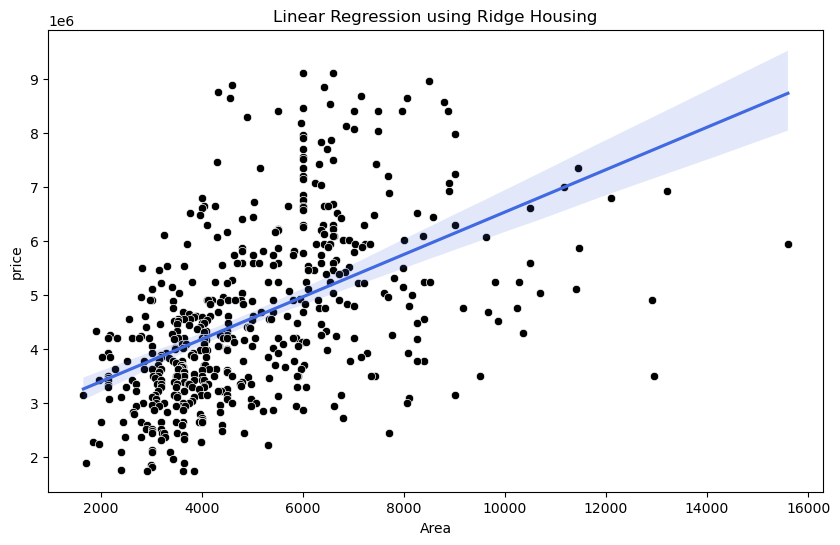

In [129]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

plt.figure(figsize= (10,6))
sns.scatterplot(
    x= 'area',
    y = 'price',
    data = df,
    color = 'black'
)
sns.regplot(x= 'area',
    y = 'price',
    data = df,
    scatter= False,
    color= 'royalblue')

plt.xlabel('Area')
plt.ylabel('price')
plt.title('Linear Regression using Ridge Housing')
plt.show()


In [130]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0))
])

lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 782366.4182701319
RMSE: 1299311.1716713149
R2: 0.3381014549097022


In [131]:
elastic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(
        alpha=1.0,
        l1_ratio=0.5
    ))
])

elastic_model.fit(X_train, y_train)

y_pred = elastic_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 804938.8819462912
RMSE: 1054897.1318833944
R2: 0.5636999081906096
